In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
def create_binary_data_2d(n=100):
    means = [[-1, 0], [1, 0]]
    cov = [[0.3, 0.2], [0.2, 0.3]]

    np.random.seed(42)
    x_1 = np.random.multivariate_normal(means[0], cov, n)
    x_2 = np.random.multivariate_normal(means[1], cov, n)

    x = np.concatenate((x_1, x_2), axis=0)
    labels = np.concatenate((np.ones(n), np.zeros(n)))

    return x_1, x_2, labels

def create_binary_data_3d(n=100):
    means = [[-1, 0, 0], [1, 0, 0]]
    cov = [
        [0.3, 0.2, 0.2],
        [0.2, 0.3, 0.2],
        [0.2, 0.2, 0.3]
    ]

    np.random.seed(42)
    x_1 = np.random.multivariate_normal(means[0], cov, n)
    x_2 = np.random.multivariate_normal(means[1], cov, n)

    x = np.concatenate((x_1, x_2), axis=0)
    labels = np.concatenate((np.ones(n), np.zeros(n)))

    return x_1, x_2, labels

In [3]:
x1_2d, x2_2d, labels_2d = create_binary_data_2d(n=20)
x1_3d, x2_3d, labels_3d = create_binary_data_3d(n=20)
print(f'2d - class 1: {x1_2d.shape} class 2: {x2_2d.shape} labels: {labels_2d.shape}')
print(f'3d - class 1: {x1_3d.shape} class 2: {x2_3d.shape} labels: {labels_3d.shape}')


2d - class 1: (20, 2) class 2: (20, 2) labels: (40,)
3d - class 1: (20, 3) class 2: (20, 3) labels: (40,)


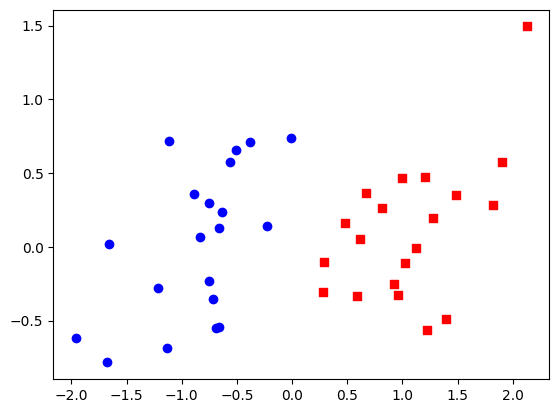

In [4]:
plt.scatter(x1_2d[:, 0], x1_2d[:, 1], c='b', marker='o', label='class 1')
plt.scatter(x2_2d[:, 0], x2_2d[:, 1], c='r', marker='s', label='class 2')
plt.show()

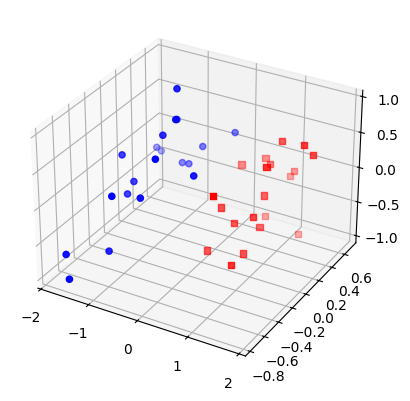

In [5]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1_3d[:, 0], x1_3d[:, 1], x1_3d[:, 2], c='b', marker='o', label='class 1')
ax.scatter(x2_3d[:, 0], x2_3d[:, 1], x2_3d[:, 2], c='r', marker='s', label='class 1')
plt.show()

In [16]:
def sigmoid(s):
    return 1 / (1 + np.exp(-s))

def loss(prob, y):
    return -np.mean(y * np.log(prob) + (1 - y) * np.log(1 - prob))

class LogisticRegression:
    def __init__(self):
        self.w = None
        self.history_loss = []

    def predict_prob(self, X):
        ones = np.ones((X.shape[0], 1))
        X = np.concatenate((ones, X), axis=1)
        return sigmoid(X @ self.w)

    def predict(self, X):
        if self.predict_prob(X) >= 0.5:
            return 1
        return 0

    def fit(self, X, y, epochs=100, lr=0.01):
        n, d = X.shape
        ones = np.ones((X.shape[0], 1))
        X = np.concatenate((ones, X), axis=1) # kich thuoc (40, 3)
                                            # kich thuoc y (40, )
        self.w = np.random.randn(d + 1) # kich thuoc (3, )

        for epoch in range(epochs):
            w_old = self.w.copy()
            #Stochastic Gradient Descent
            #shuffle = np.random.permutation(n)
            # for i in shuffle:
            #     Xi = X[i]
            #     yi = y[i]
            #     zi = sigmoid(Xi @ self.w)
            #     self.w -= lr * (zi - yi) * Xi

            #Batch Gradient Descent
            z = sigmoid(X @ self.w)
            self.w = self.w - lr * ((z - y).T @ X).T

            probs = sigmoid(X @ self.w)
            self.history_loss.append(loss(probs, y))

            if np.linalg.norm(self.w - w_old) / d < 0.01:
                break

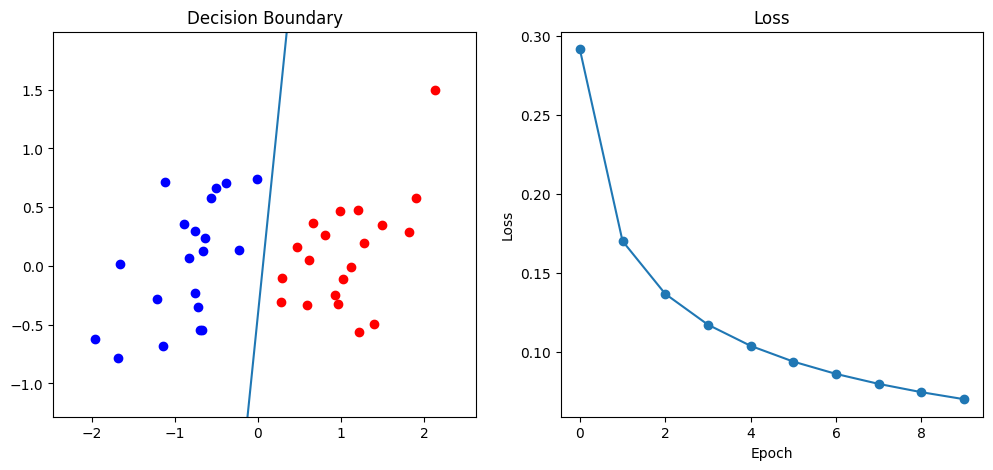

In [17]:
X = np.concatenate((x1_2d, x2_2d), axis=0)

model = LogisticRegression()
model.fit(X, labels_2d, lr=0.1, epochs=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.set_xlim([X[:, 0].min() - 0.5, X[:, 0].max() + 0.5])
ax.set_ylim([X[:, 1].min() - 0.5, X[:, 1].max() + 0.5])
ax.scatter(x1_2d[:, 0], x1_2d[:, 1], c='b')
ax.scatter(x2_2d[:, 0], x2_2d[:, 1], c='r')

x = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)
y = -(model.w[1] / model.w[2]) * x - (model.w[0] / model.w[2])
ax.plot(x, y)
ax.set_title("Decision Boundary")

ax2 = axes[1]
ax2.plot(model.history_loss, marker='o')
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")

plt.show()

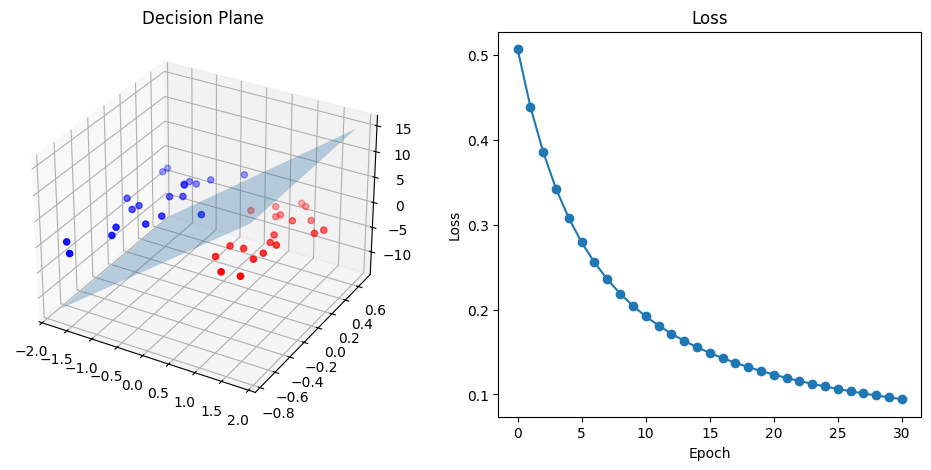

In [8]:
X = np.concatenate((x1_3d, x2_3d), axis=0)

model = LogisticRegression()
model.fit(X, labels_3d, lr=0.01, epochs=100)

fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(121, projection='3d')

ax.scatter(x1_3d[:, 0], x1_3d[:, 1], x1_3d[:, 2], c='b')
ax.scatter(x2_3d[:, 0], x2_3d[:, 1], x2_3d[:, 2], c='r')

x = np.linspace(X[:,0].min(), X[:,0].max(), 20)
y = np.linspace(X[:,1].min(), X[:,1].max(), 20)
xx, yy = np.meshgrid(x, y)

zz = -(model.w[1] / model.w[3])*xx - (model.w[2] / model.w[3])*yy - (model.w[0] / model.w[3])
ax.plot_surface(xx, yy, zz, alpha=0.3)

ax.set_title("Decision Plane")

ax2 = fig.add_subplot(122)
ax2.plot(model.history_loss, marker='o')
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")

plt.show()